In [16]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [17]:
shp_path = "data/calenviroscreen40_shp/CES4 Final Shapefile.shp"
shape = gpd.read_file(shp_path)
shape = shape.replace([-999, -1998], np.nan)

In [18]:
pctl_cols = [
    'CIscoreP','OzoneP','PM2_5_P','DieselPM_P','PesticideP','Tox_Rel_P',
    'TrafficP','DrinkWatP','Lead_P','CleanUpP','GWThreatP','HazWasteP',
    'ImpWatBdP','SolWasteP','PolBurdP','AsthmaP','LowBirWP','CardiovasP',
    'EducatP','Ling_IsolP','PovertyP','UnemplP','HousBurdP','PopCharP'
]
race_cols = ['Hispanic','White','AfricanAm','NativeAm','OtherMult','AAPI']

for c in (pctl_cols + race_cols):
    if c in shape.columns:
        shape[c] = pd.to_numeric(shape[c], errors="coerce")

shape = shape.to_crs(epsg=3857)

In [19]:
def qmap(shape, col, title=None, cmap="viridis", k=6, figsize=(10,10), save=None, bins=None):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_axis_off()

    if bins is None:
        # quantiles (different per race variable)
        shape.plot(
            column=col, scheme="quantiles", k=k, cmap=cmap, legend=True, ax=ax,
            edgecolor="white", linewidth=0.08,
            missing_kwds={"color": "lightgrey", "label": "Missing"},
            legend_kwds={"loc": "lower left"}
        )
    else:
        # fixed bins (same legend across variables)
        shape.plot(
            column=col, scheme="user_defined", classification_kwds={"bins": bins},
            cmap=cmap, legend=True, ax=ax,
            edgecolor="white", linewidth=0.08,
            missing_kwds={"color": "lightgrey", "label": "Missing"},
            legend_kwds={"loc": "lower left"}
        )

    ax.set_title(title if title else col, fontsize=14)
    plt.show()

In [20]:
burden = "PolBurdP"
# burden = "CIscoreP"

In [21]:
exposure_vars = ["OzoneP", "PM2_5_P", "DieselPM_P", "TrafficP", "Tox_Rel_P", "PesticideP"]
shape["ExposureIdx"] = shape[exposure_vars].mean(axis=1, skipna=True)
# burden = "ExposureIdx"

--- Hispanic ---


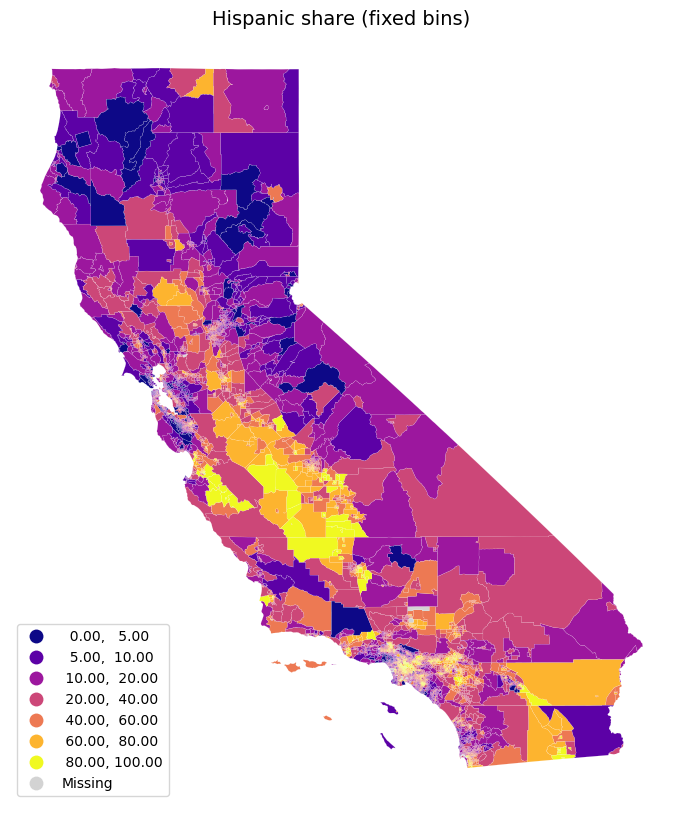

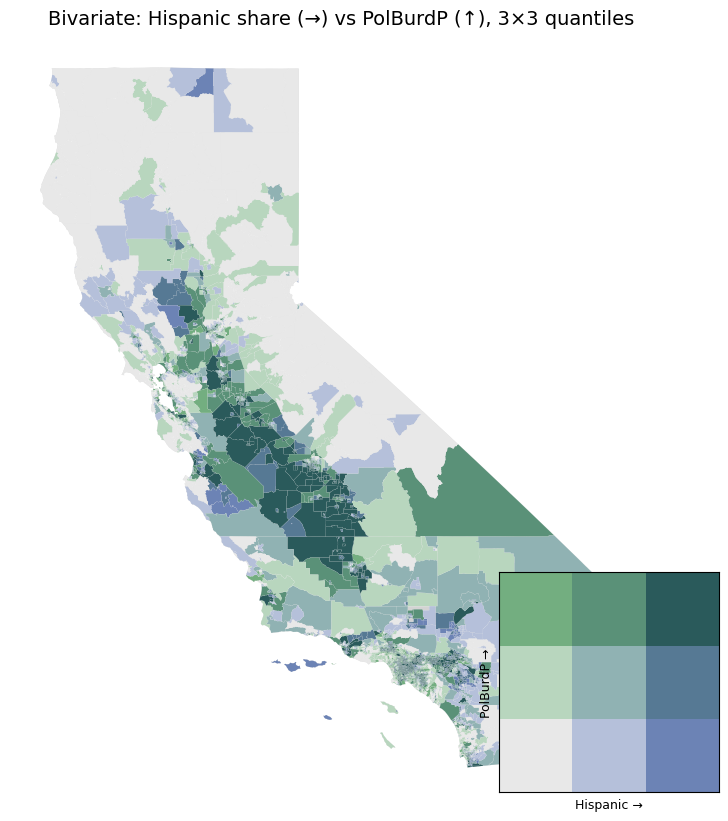

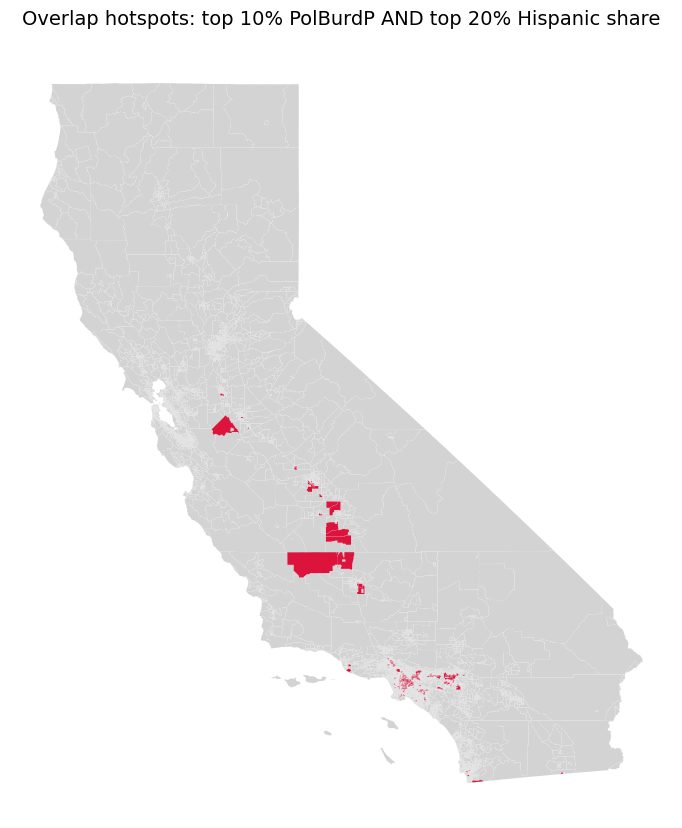

--- White ---


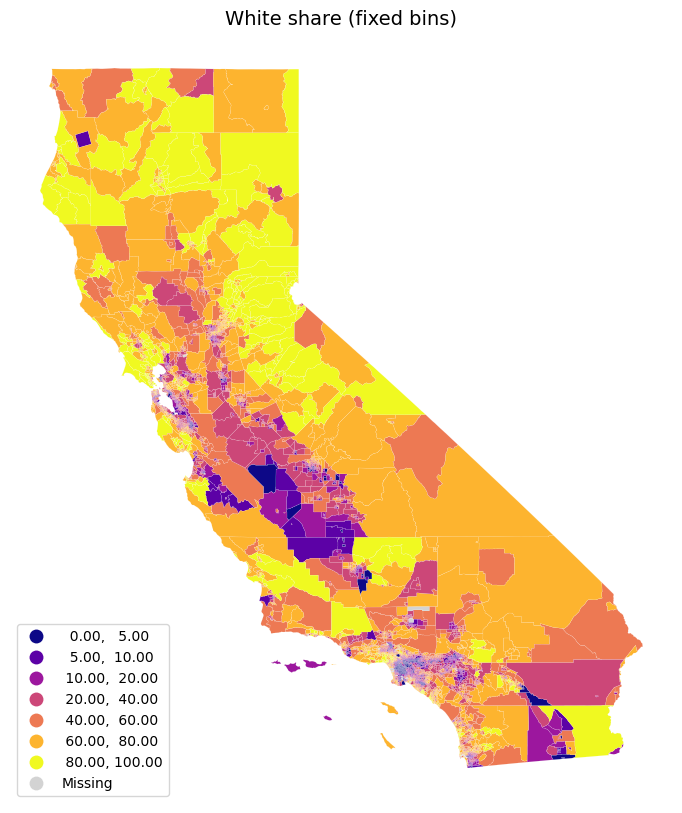

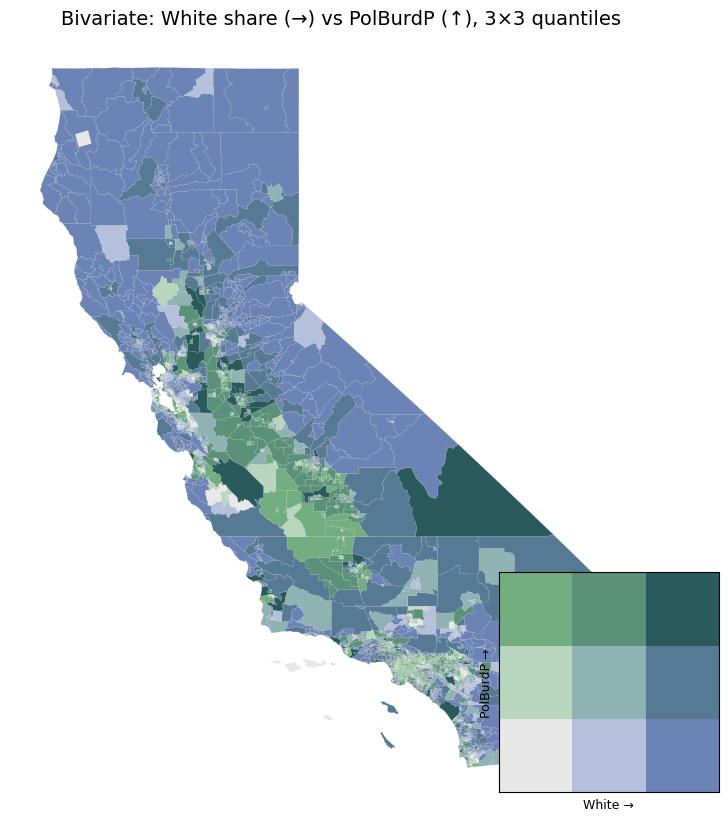

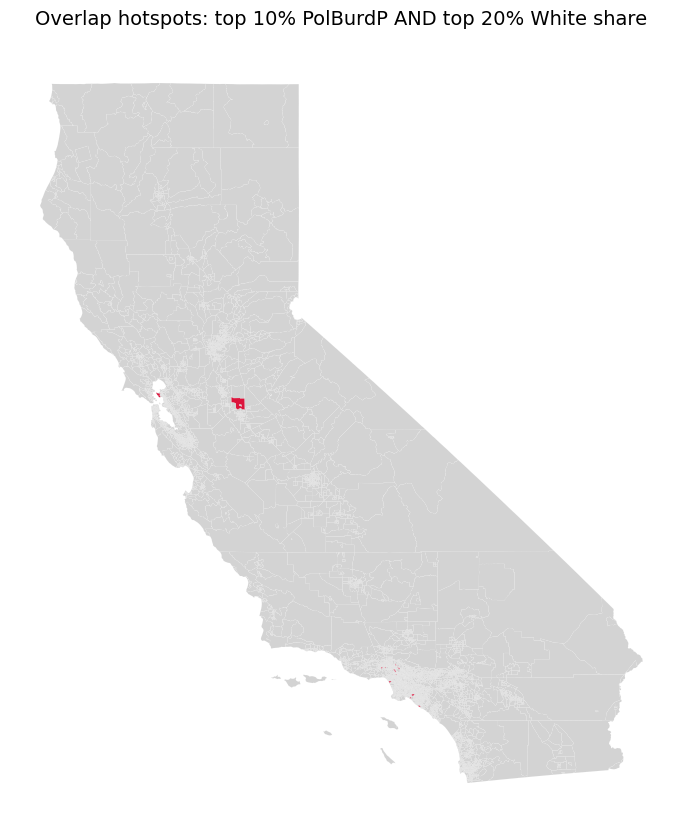

--- AfricanAm ---


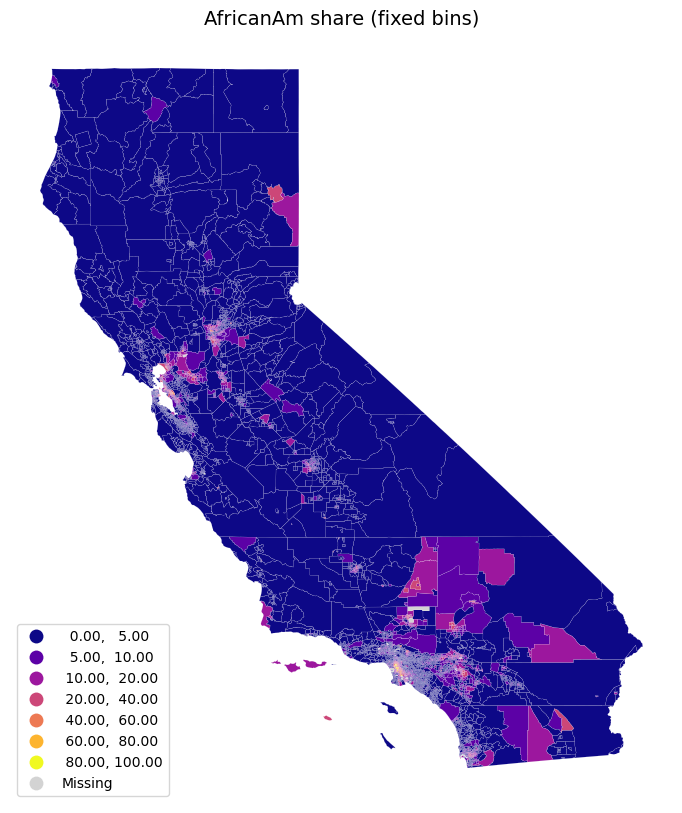

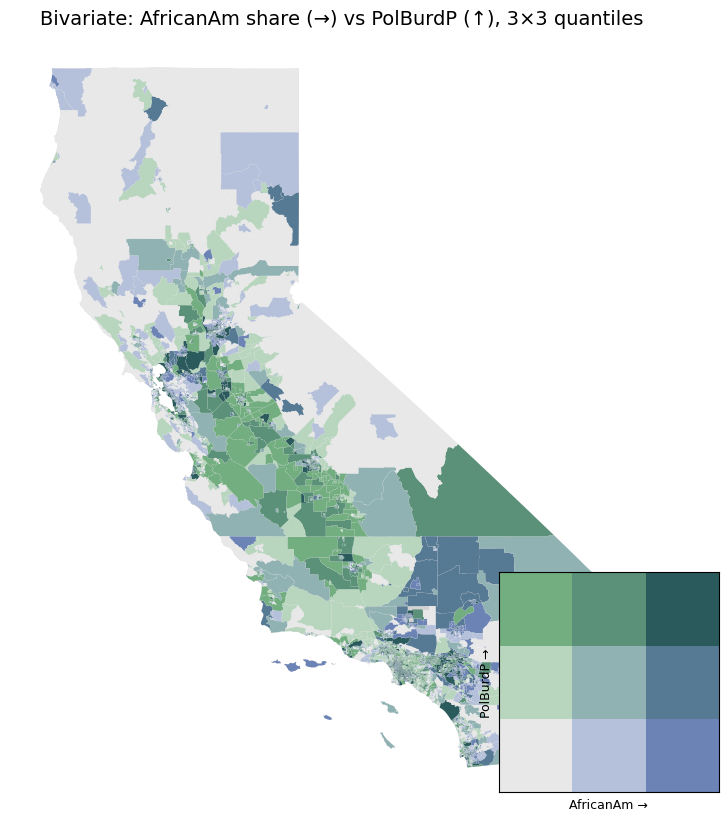

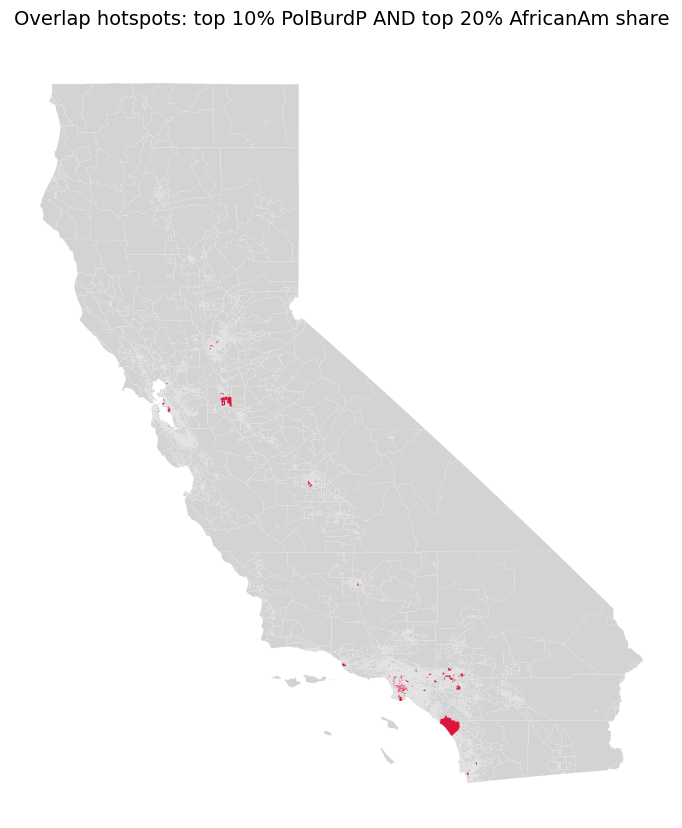

--- NativeAm ---


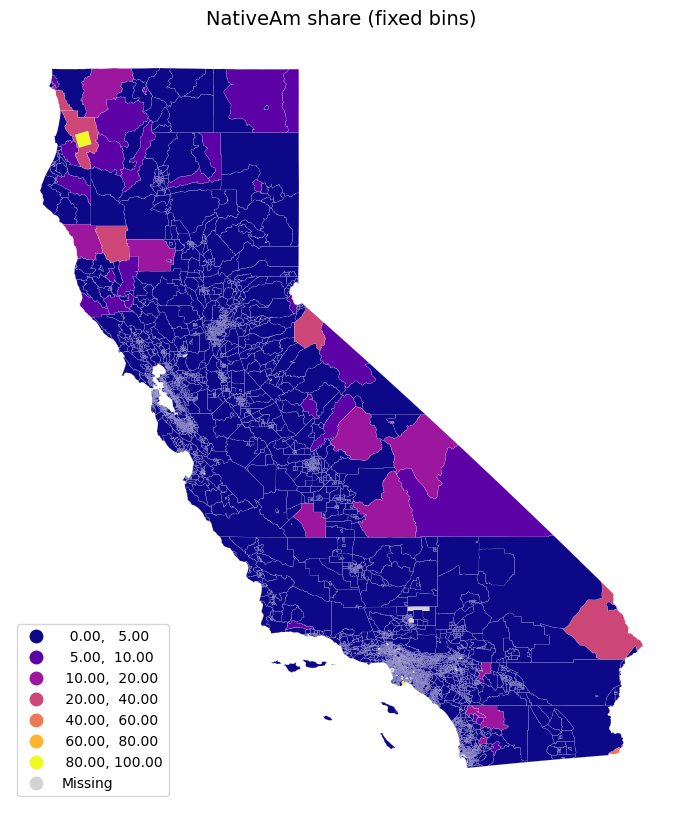

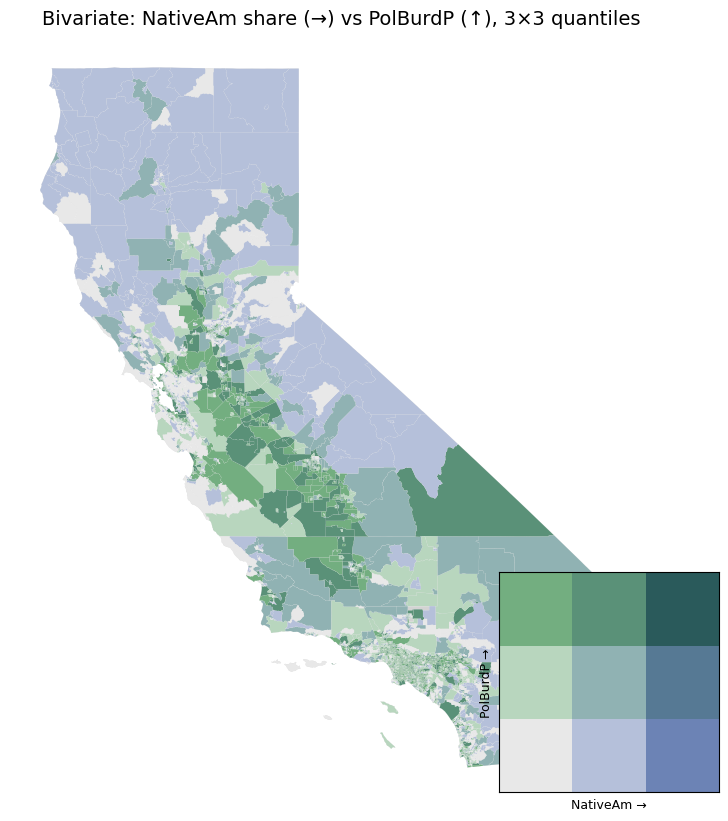

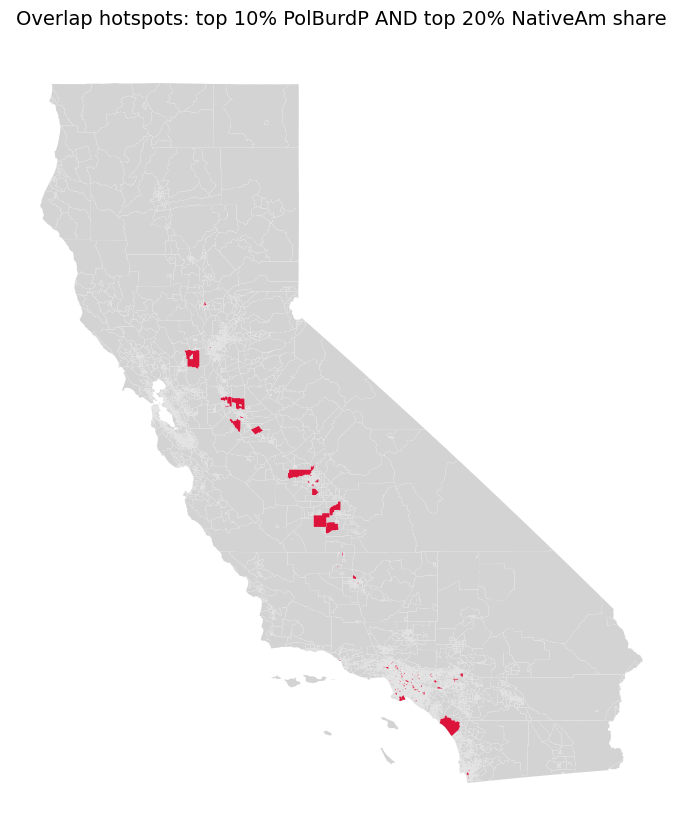

--- OtherMult ---


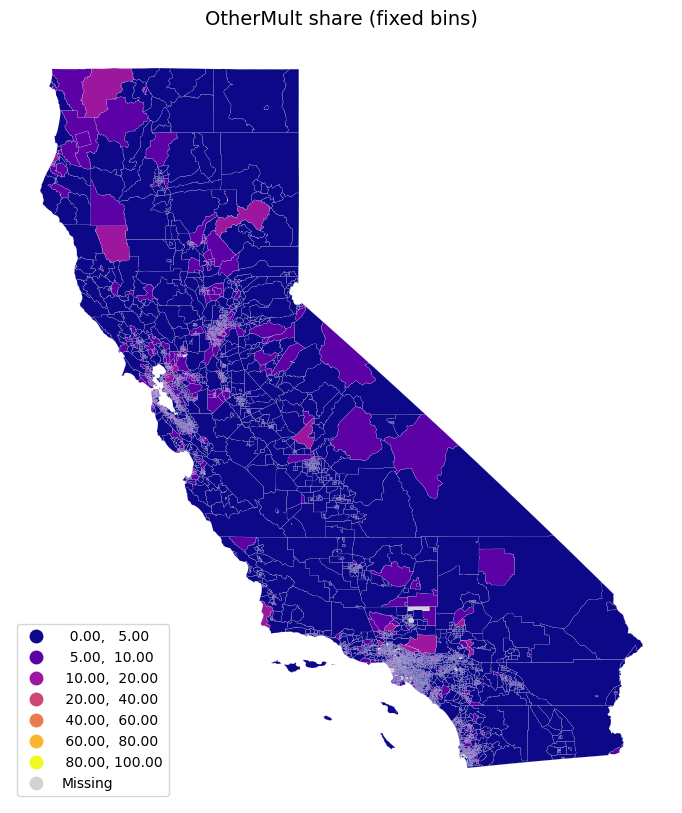

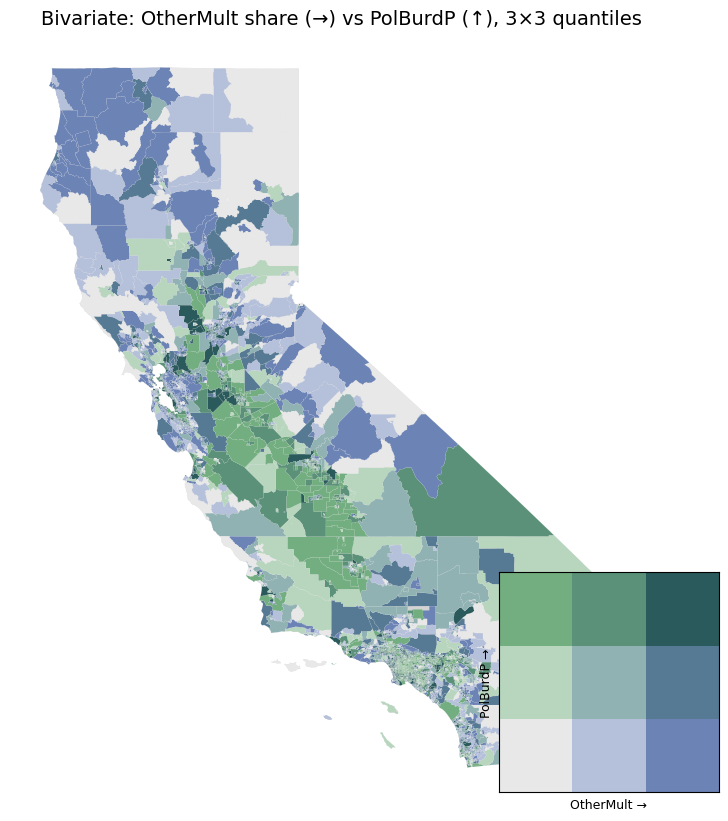

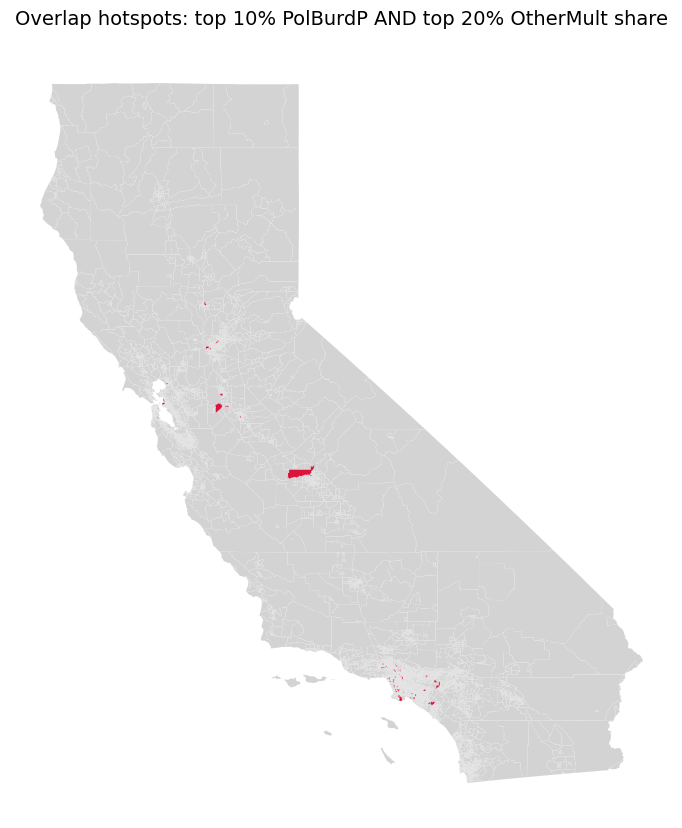

--- AAPI ---


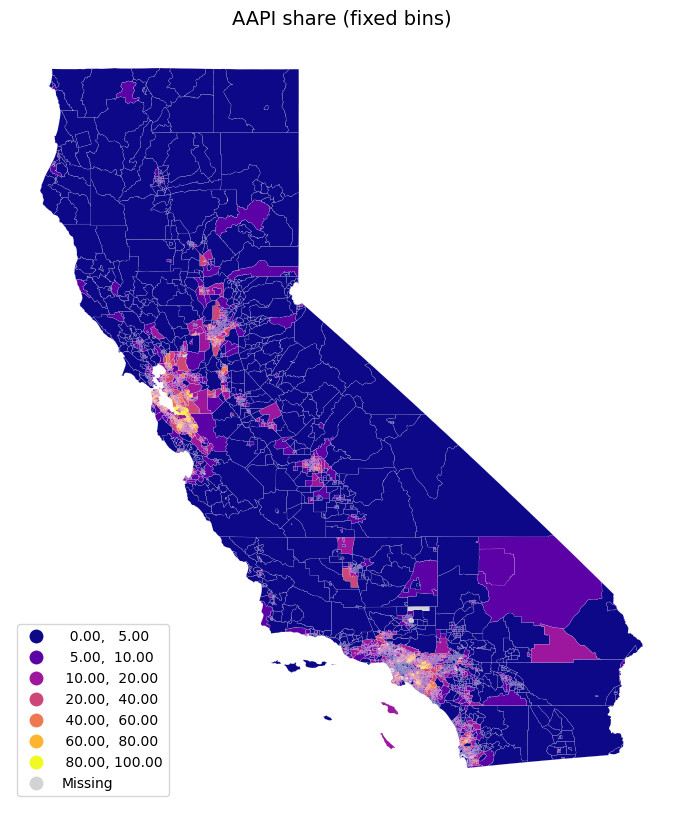

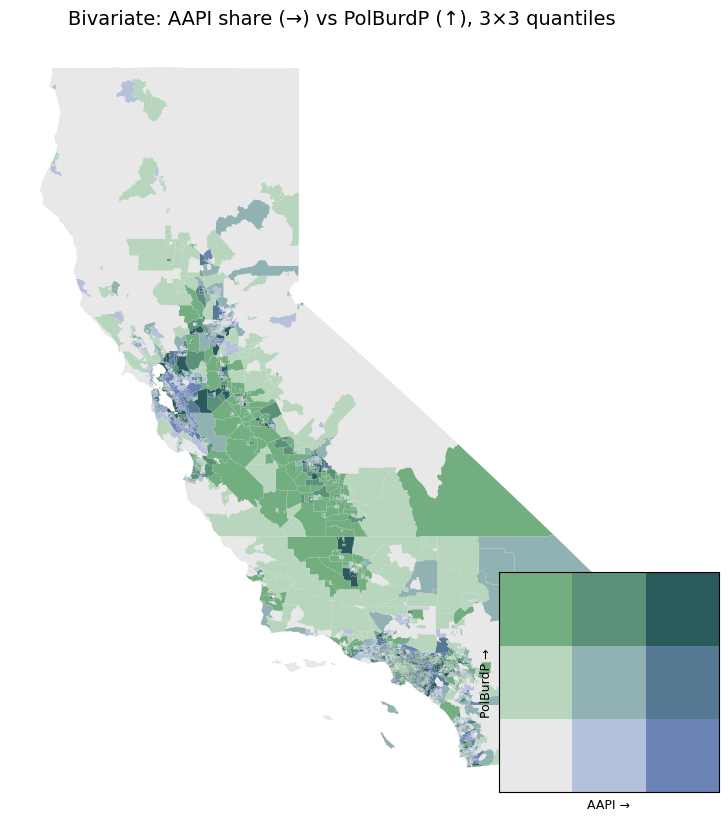

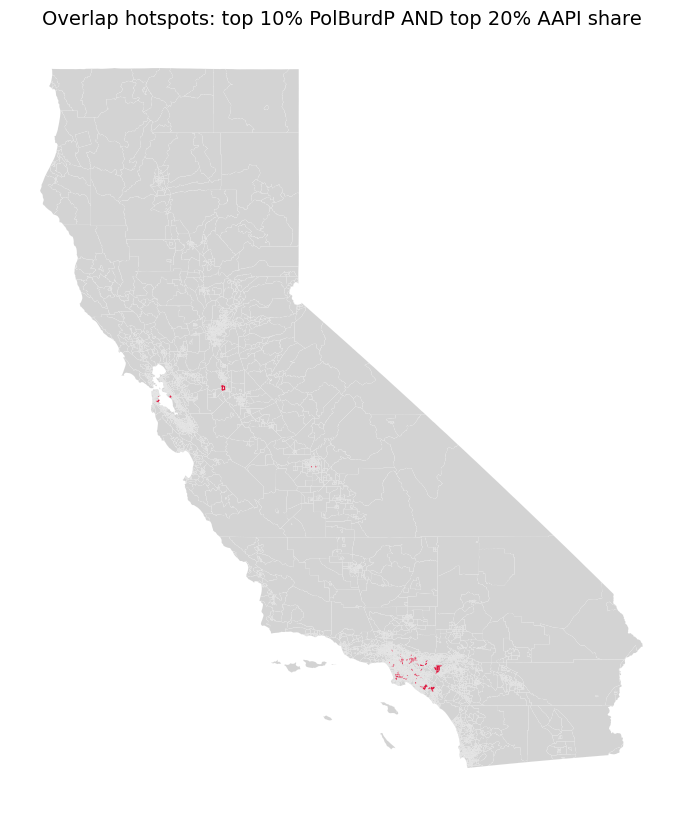

In [22]:
race_bins = [5, 10, 20, 40, 60, 80, 100]
for race in race_cols:
    print(f"--- {race} ---")

    # 1: Map depicting race share (for each race)
    qmap(
        shape,
        race,
        title=f"{race} share (fixed bins)",
        cmap="plasma",
        bins=race_bins,
        save=f"race_{race}_fixedbins.png"
    )

    # 2) Bivariate map: race share (x) vs burden (y), 3×3 quantiles

    df = shape[[race, burden, "geometry"]].dropna().copy()

    # quantile bins: 0 = low, 1 = mid, 2 = high
    df["race_bin"] = pd.qcut(df[race], 3, labels=False, duplicates="drop")
    df["burden_bin"] = pd.qcut(df[burden], 3, labels=False, duplicates="drop")

    df["bi"] = df["race_bin"].astype(int) + 3 * df["burden_bin"].astype(int)

    # rows = burden (low to high), cols = race (low to high)
    colors = [
        "#e8e8e8", "#b5c0da", "#6c83b5",   # low burden
        "#b8d6be", "#90b2b3", "#567994",   # mid burden
        "#73ae80", "#5a9178", "#2a5a5b"    # high burden
    ]
    df["color"] = df["bi"].map(lambda i: colors[int(i)])

    fig, ax = plt.subplots(1, 1, figsize=(10,10))
    ax.set_axis_off()

    # base map
    shape.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.05)
    df.plot(ax=ax, color=df["color"], edgecolor="white", linewidth=0.05)

    ax.set_title(
        f"Bivariate: {race} share (→) vs {burden} (↑), 3×3 quantiles",
        fontsize=14
    )

    # legend (3×3 grid)
    leg = fig.add_axes([0.67, 0.12, 0.22, 0.22])
    leg.set_xticks([]); leg.set_yticks([]); leg.set_frame_on(True)

    k = 0
    for j in range(3):          # burden: low -> high
        for i in range(3):      # race: low -> high
            leg.add_patch(
                plt.Rectangle((i, j), 1, 1, facecolor=colors[k], edgecolor="none")
            )
            k += 1

    leg.set_xlim(0, 3); leg.set_ylim(0, 3)
    leg.set_xlabel(f"{race} →", fontsize=9)
    leg.set_ylabel(f"{burden} →", fontsize=9)
    plt.show()

    # 3) Overlap hotspots: top 10% burden AND top 20% race share
    cut_hi = shape[race].quantile(0.80)
    burden_hot = shape[burden].quantile(0.90)
    overlap = (shape[burden] >= burden_hot) & (shape[race] >= cut_hi)

    fig, ax = plt.subplots(1, 1, figsize=(10,10))
    ax.set_axis_off()
    shape.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.05)
    shape.loc[overlap].plot(ax=ax, color="crimson", edgecolor="white", linewidth=0.05)
    ax.set_title(f"Overlap hotspots: top 10% {burden} AND top 20% {race} share", fontsize=14)
    plt.show()